In [10]:
#imports
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import quad
from IPython.display import display

#### Questao 1

### Letra a


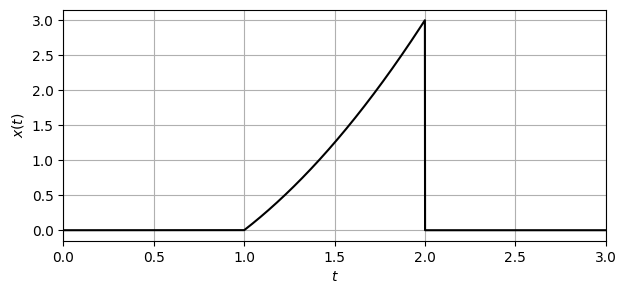

In [ ]:
#letra A
t_ini = 0
t_fim  = 3
n_pontos = 10000

t = np.linspace(t_ini, t_fim, n_pontos)

u1 = 1.0 * (t >= 1)
u2 = 1.0 * (t >= 2)

x = (t**2 - 1) * (u1 - u2)



plt.figure(figsize=(7,3))
plt.plot(t,x, 'k')
plt.xlabel('$t$')
plt.ylabel('$x(t)$')
plt.xlim([t_ini, t_fim])
plt.grid()
plt.show()


### Letra b



Para determinar a energia total $E_x$ de um sinal em tempo contínuo, aplicamos a definição padrão da integral de seu módulo ao quadrado: $E_x = \int_{-\infty}^{\infty} |x(t)|^2 dt$.

Como a diferença entre as funções degrau unitário restringe o intervalo de existência do sinal, ele assume valores não nulos exclusivamente no trecho compreendido entre $t = 1$ e $t = 2$. Com isso, ajustamos os limites de integração e expandimos o binômio:

$$E_x = \int_{1}^{2} (t^2 - 1)^2 dt = \int_{1}^{2} (t^4 - 2t^2 + 1) dt$$

Ao calcularmos a integral definida, obtemos a seguinte primitiva:

$$E_x = \left[ \frac{t^5}{5} - \frac{2t^3}{3} + t \right]_{1}^{2}$$

Por fim, aplicando os limites de integração no intervalo e resolvendo as frações, chegamos ao valor final da energia do sinal:

$$E_x = \left( \frac{32}{5} - \frac{16}{3} + 2 \right) - \left( \frac{1}{5} - \frac{2}{3} + 1 \right) = \frac{31}{5} - \frac{14}{3} + 1 = \frac{93 - 70 + 15}{15} = \frac{38}{15} \approx 2.5333$$

### Letra c


A avaliação numérica da energia do sinal consiste em aproximar a integral contínua $E_x = \int_{-\infty}^{\infty} |x(t)|^2 dt$ por meio de uma soma de Riemann. Para isso, utilizamos as amostras discretizadas no vetor de tempo:

$$E_{num} \approx \sum_{i} |x(t_i)|^2 \cdot \Delta t$$

Nesta formulação:

* $x(t_i)$ representa a amplitude do sinal avaliada em cada instante discreto $i$.
* $\Delta t$ corresponde à resolução temporal, ou seja, o espaçamento constante (passo de integração) entre amostras consecutivas.

In [ ]:
#Letra c
dt = (t_fim - t_ini) / n_pontos
exp_num = np.sum(x**2) * dt

print(f'Metodo computacional = {exp_num:.4f}')
print(f'Metodo analítico = 2.5333')

Energia (computacional) = 2.5317
Energia (analítica) = 2.5333


#### Questão 2

### Letra a

A partir da análise da Figura 1, nota-se que o sinal é construído pela composição de dois comportamentos distintos: um patamar de amplitude constante e uma curva de decaimento exponencial. Podemos descrever esses trechos da seguinte forma:

* **Trecho constante:** O sinal apresenta valor fixo igual a $2$, restrito ao intervalo de tempo $-1.5 \le t < 0$.
* **Trecho exponencial:** O sinal segue a função de decaimento $2e^{-t/2}$, válido durante o intervalo $0 \le t \le 3$.

Para unificar essas características em uma única equação matemática, utilizamos a diferença entre funções degrau unitário $u(t)$ para criar "janelas" que ativam e desativam cada trecho em seus respectivos limites de tempo:

$$x(t) = 2[u(t+1.5) - u(t)] + 2e^{-t/2}[u(t) - u(t-3)]$$

### Letra b

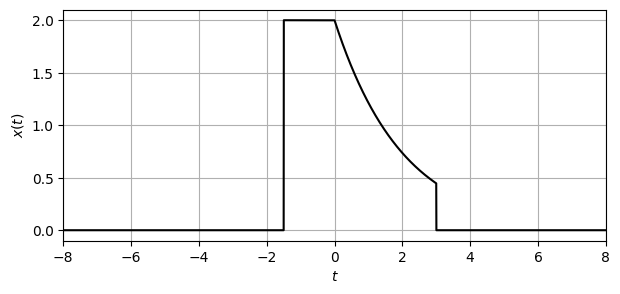

In [ ]:
#Letra b
def sinal(t):
    return 2*(np.logical_and(t >= -1.5, t < 0)) + (2*np.exp(-t/2))*(np.logical_and(t >= 0, t <= 3))

t_ini =-8
t_fim = 8
n_pontos = 10000
t = np.linspace(t_ini, t_fim, n_pontos)
x = sinal(t)


plt.figure(figsize=(7,3))
plt.plot(t,x, 'k')
plt.xlabel('$t$')
plt.ylabel('$x(t)$')
plt.xlim([t_ini, t_fim])
plt.grid()
plt.show()


### Letra c

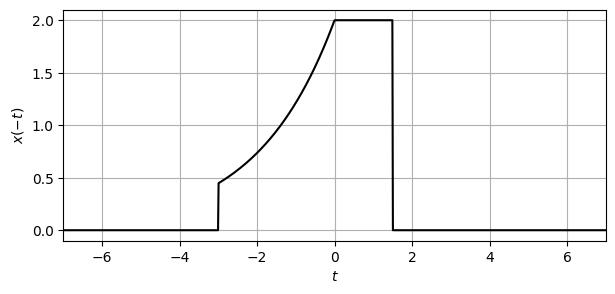

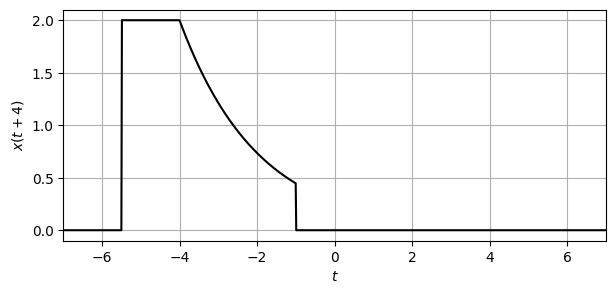

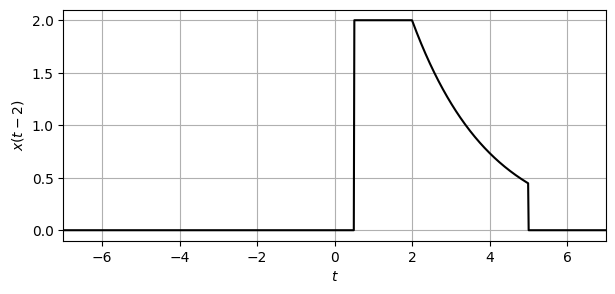

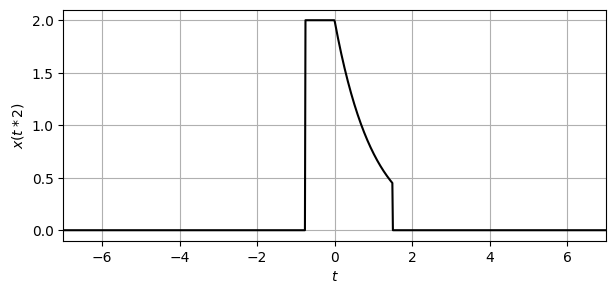

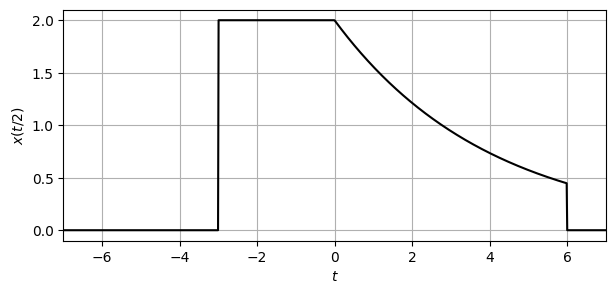

In [ ]:
#Letra c
t_ini =-7
t_fim = 7
n_pontos = 1000
t = np.linspace(t_ini, t_fim, n_pontos)
x1 = sinal(-t) # Reversão no tempo / espelhamento no eixo y
x2 = sinal(t+4) # Deslocamento de 4 unidades a esquerda 
x3 = sinal(t-2) # Deslocamento de 2 unidades a direita
x4 = sinal(t*2) # Compressão no eixo do tempo com fator 2
x5 = sinal(t/2) # Expansão no eixo do tempo com fator 2


plt.figure(figsize=(7,3))
plt.plot(t,x1, 'k')
plt.xlabel('$t$')
plt.ylabel('$x(-t)$')
plt.xlim([t_ini, t_fim])
plt.grid()
plt.show()

plt.figure(figsize=(7,3))
plt.plot(t,x2, 'k')
plt.xlabel('$t$')
plt.ylabel('$x(t + 4)$')
plt.xlim([t_ini, t_fim])
plt.grid()
plt.show()

plt.figure(figsize=(7,3))
plt.plot(t,x3, 'k')
plt.xlabel('$t$')
plt.ylabel('$x(t - 2)$')
plt.xlim([t_ini, t_fim])
plt.grid()
plt.show()

plt.figure(figsize=(7,3))
plt.plot(t,x4, 'k')
plt.xlabel('$t$')
plt.ylabel('$x(t * 2)$')
plt.xlim([t_ini, t_fim])
plt.grid()
plt.show()

plt.figure(figsize=(7,3))
plt.plot(t,x5, 'k')
plt.xlabel('$t$')
plt.ylabel('$x(t / 2)$')
plt.xlim([t_ini, t_fim])
plt.grid()
plt.show()



#### Questão 3

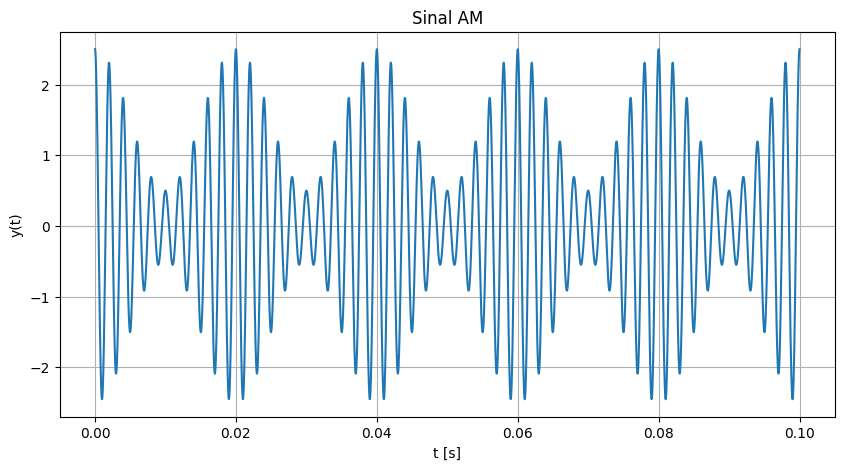

In [21]:
freq_m = 50
freq_c = 500
A = 1.5

t = np.linspace(0, 0.1, 5000)

x = np.cos(2 * np.pi * freq_m * t)
y = (A + x) * np.cos(2 * np.pi * freq_c * t)

plt.figure(figsize=(10, 5))
plt.plot(t, y)
plt.title("Sinal AM")
plt.xlabel("t [s]")
plt.ylabel("y(t)")
plt.grid(True)
plt.show()

#### Questão 4

### Letra a

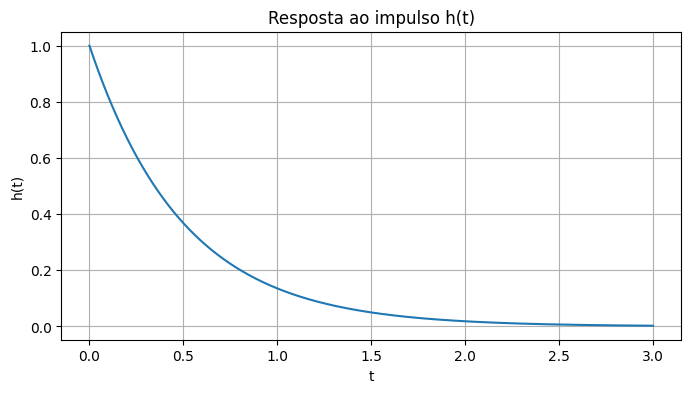

In [ ]:
#Letra a
t= np.linspace(0, 3, 1000)
h = np.exp(-2*t)

plt.figure(figsize=(8, 4))
plt.plot(t, h)
plt.title("Resposta ao impulso h(t)")
plt.xlabel("t")
plt.ylabel("h(t)")
plt.grid(True)
plt.show()

### Letra b

A resposta ao impulso que caracteriza o sistema é definida pela expressão:

$$h(t) = e^{-2t}u(t)$$

Para classificar o sistema quanto à causalidade, analisamos o comportamento de $h(t)$ no semi-eixo negativo de tempo. Devido à multiplicação pela função degrau unitário $u(t)$, a resposta ao impulso é estritamente nula para valores negativos:

$$h(t) = 0, \quad t < 0$$

Isso comprova que o sistema não produz nenhuma saída antes que um estímulo (entrada) seja aplicado, confirmando a sua **causalidade**.

Para avaliar a estabilidade do sistema, verificamos se para uma entrada limitada, sempre temos uma saida limitada, para Sistemas Lineares e Invariantes no Tempo (LIT). A condição fundamental exige que a resposta ao impulso seja absolutamente integrável:

$$\int_{-\infty}^{\infty} |h(t)| dt < \infty$$

Substituindo a expressão de $h(t)$ e ajustando o limite inferior da integral em função da atuação do degrau unitário, temos:

$$\int_{-\infty}^{\infty} |h(t)| dt = \int_0^{\infty} e^{-2t} dt$$

Desenvolvendo o cálculo da integral definida:

$$\int_0^{\infty} e^{-2t} dt = \left[-\frac{1}{2}e^{-2t}\right]_0^{\infty}$$

$$= 0 - \left(-\frac{1}{2}\right) = \frac{1}{2}$$

Uma vez que a integral converge para um valor numérico finito ($1/2$), a condição de entrada limitadae saida limitada é perfeitamente satisfeita. Portanto, conclui-se que o sistema é **estável**.

Em síntese, o sistema analisado é classificado como **causal e estável**.

### Letra C

### Cálculo da Saída do Sistema via Convolução

A saída $y(t)$ de um sistema Linear e Invariante no Tempo (LIT) é definida pela convolução entre o sinal de entrada $x(t)$ e a resposta ao impulso $h(t)$:

$$y(t) = x(t) * h(t)$$

Dado que o sinal de entrada é um pulso retangular formado pela diferença de dois degraus, $x(t) = u(t) - u(t-2)$, e a resposta ao impulso é $h(t) = e^{-2t}u(t)$, substituímos $x(t)$ na equação principal:

$$y(t) = [u(t) - u(t-2)] * h(t)$$

Aplicando a propriedade distributiva (linearidade) da convolução, podemos dividir o problema em duas parcelas mais simples:

$$y(t) = u(t)*h(t) - u(t-2)*h(t)$$

Primeiramente, calculamos a primeira parcela, que representa a resposta ao degrau do sistema. Chamaremos essa resposta de $s(t)$:

$$s(t) = u(t)*h(t) = \int_{-\infty}^{\infty} u(\tau)e^{-2(t-\tau)}u(t-\tau) d\tau$$

As funções degrau definem os limites de integração: $u(\tau)$ zera a integral para $\tau < 0$, e $u(t-\tau)$ zera a integral para $\tau > t$. Assim, a avaliação ocorre apenas no intervalo $0 \le \tau \le t$:

$$s(t) = \int_0^t e^{-2(t-\tau)} d\tau$$

Isolando a constante $e^{-2t}$ em relação a $\tau$:

$$s(t) = e^{-2t}\int_0^t e^{2\tau} d\tau$$

Resolvendo a integral definida:

$$s(t) = e^{-2t}\left[\frac{e^{2\tau}}{2}\right]_0^t = e^{-2t}\left(\frac{e^{2t}-1}{2}\right)$$

Multiplicando os termos:

$$s(t) = \frac{1-e^{-2t}}{2}$$

Para formalizar que essa resposta só existe para $t \ge 0$, multiplicamos o resultado pela função degrau unitário:

$$s(t) = u(t)\frac{1-e^{-2t}}{2}$$

Como o sistema é Invariante no Tempo, a convolução do segundo termo da nossa equação original ($u(t-2)*h(t)$) será exatamente a mesma resposta ao degrau que acabamos de calcular, mas com um atraso de $2$ segundos. Ou seja, a saída total é a superposição:

$$y(t) = s(t) - s(t-2)$$

Substituindo a expressão de $s(t)$ em ambos os termos, chegamos à equação final da saída do sistema:

$$\boxed{
y(t) = u(t)\frac{1-e^{-2t}}{2} - u(t-2)\frac{1-e^{-2(t-2)}}{2}
}$$

### Letra D

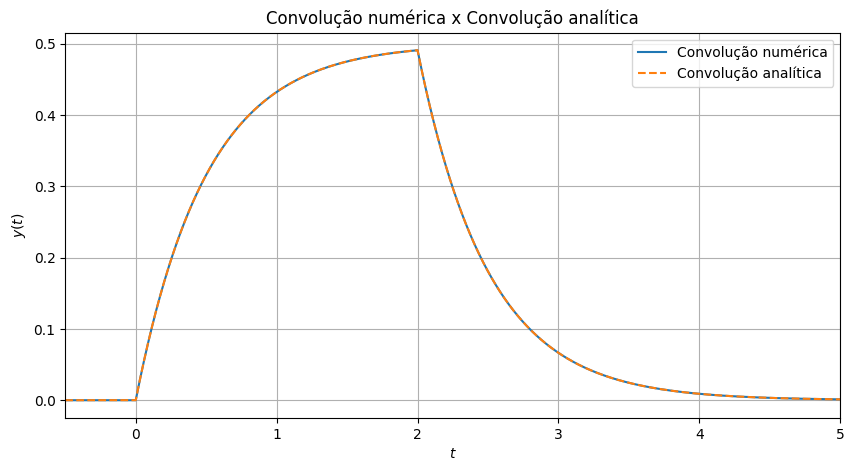

In [ ]:
#Letra D

def u(t):
    return 1.0*(t >= 0)

t_ini = -1
t_fim = 6
n_pontos = 10000

t = np.linspace(t_ini, t_fim, n_pontos)
dt = t[1] - t[0]

x = u(t) - u(t - 2)
h = np.exp(-2*t) * u(t)

y_n = dt * np.convolve(x, h, mode='full')

t_y = np.linspace(2*t_ini, 2*t_fim, len(y_n))

y_a = np.zeros_like(t_y)

cond1 = (t_y >= 0) & (t_y < 2)
cond2 = (t_y >= 2)

y_a[cond1] = (1 - np.exp(-2*t_y[cond1])) / 2
y_a[cond2] = (np.exp(-2*(t_y[cond2]-2)) - np.exp(-2*t_y[cond2])) / 2

plt.figure(figsize=(10,5))
plt.plot(t_y, y_n, label='Convolução numérica')
plt.plot(t_y, y_a, '--', label='Convolução analítica')
plt.xlabel('$t$')
plt.ylabel('$y(t)$')
plt.title('Convolução numérica x Convolução analítica')
plt.grid()
plt.xlim([-0.5, 5])
plt.legend()
plt.show()

### Letra e

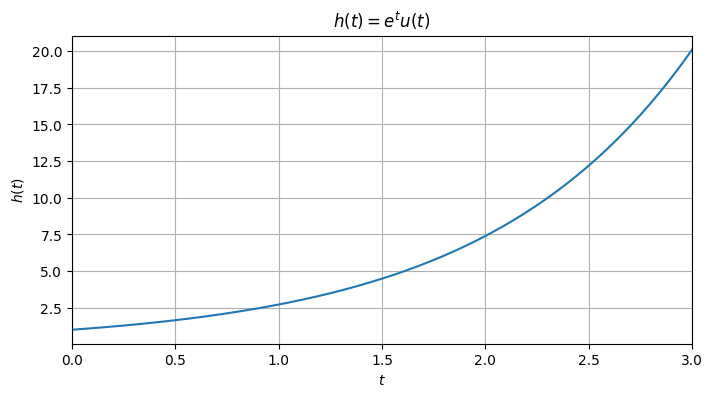

In [30]:
t_ini = 0
t_fim = 3
n_pontos = 10000

t = np.linspace(t_ini, t_fim, n_pontos)

h = np.exp(t) * (t >= 0)

plt.figure(figsize=(8,4))
plt.plot(t, h)
plt.xlabel('$t$')
plt.ylabel('$h(t)$')
plt.title('$h(t)=e^tu(t)$')
plt.grid()
plt.xlim([t_ini, t_fim])
plt.show()

### Análise de Causalidade e Estabilidade
Como o sistema não apresenta saída antes de receber uma entrada, ele é classificado como um sistema **causal**.

No entanto, ao avaliarmos a estabilidade pelo critério de integrabilidade absoluta, analisamos a área sob o módulo da resposta ao impulso:

$$ \int_0^{\infty} |e^t| dt $$

A função $e^t$ cresce indefinidamente à medida que o tempo avança. Por conta desse crescimento exponencial contínuo, a integral apresentada **diverge**. Como a condição de integrabilidade absoluta falha, concluímos inevitavelmente que o sistema é **instável**.

### Cálculo da Saída do Sistema (Caso Instável)

Agora, vamos determinar a saída do sistema considerando uma nova resposta ao impulso, de característica crescente:


$$h(t) = e^{t}u(t)$$

O sinal de entrada aplicado continua sendo o pulso retangular:


$$x(t) = u(t) - u(t-2)$$

Sabemos que a saída $y(t)$ é dada pela convolução entre o sinal de entrada e a resposta ao impulso:


$$y(t) = x(t) * h(t)$$

Substituindo a expressão de $x(t)$ e aplicando a propriedade da linearidade, podemos dividir o cálculo em duas partes mais simples:


$$y(t) = [u(t) - u(t-2)] * h(t)$$

$$y(t) = u(t)*h(t) - u(t-2)*h(t)$$

Vamos focar no primeiro termo, que chamaremos de $s(t)$. Ele representa a resposta do sistema a um único degrau unitário $u(t)$:


$$s(t) = u(t)*h(t) = \int_{-\infty}^{\infty} u(\tau)e^{t-\tau}u(t-\tau) d\tau$$

As funções degrau restringem a existência da integral ao intervalo onde ambas são não nulas, ou seja, $0 \leq \tau \leq t$:


$$s(t) = \int_0^t e^{t-\tau} d\tau$$

Como estamos integrando em relação a $\tau$, o termo $e^t$ atua como uma constante e pode sair da integral:


$$s(t) = e^t\int_0^t e^{-\tau} d\tau$$

Calculando a integral definida:


$$s(t) = e^t\left[-e^{-\tau}\right]_0^t$$

$$s(t) = e^t(-e^{-t} + 1)$$

Distribuindo a multiplicação, chegamos ao resultado:


$$s(t) = -1 + e^t = e^t - 1$$

Para garantir matematicamente que essa resposta só existe para tempos positivos, multiplicamos o resultado pela função degrau:


$$s(t) = u(t)(e^t - 1)$$

Por fim, a saída total do sistema é a composição dessa resposta $s(t)$ menos a sua versão atrasada em 2 segundos, devido à natureza da entrada:


$$y(t) = s(t) - s(t-2)$$

Substituindo a expressão encontrada com seus respectivos tempos, temos a equação final da saída:

$$\boxed{
y(t) = u(t)(e^t - 1) - u(t-2)(e^{t-2} - 1)
}$$

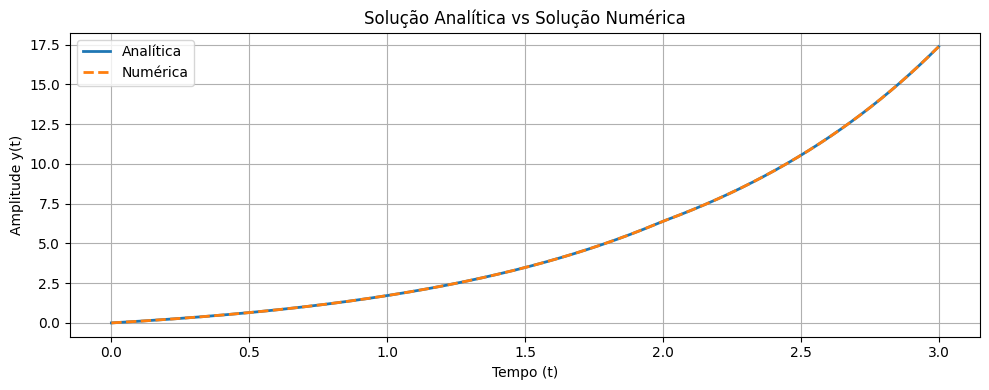

In [ ]:
#Letra e
dt = 0.001

t = np.arange(0, 3, dt)

x = np.where((t >= 0) & (t < 2), 1, 0)
h = np.exp(t)

y_n = np.convolve(x, h, mode="full") * dt
t_conv = np.arange(0, len(y_n)) * dt

def solucao_analitica(t_array):
    return np.where(
        t_array < 0,
        0,
        np.where(
            t_array < 2,
            np.exp(t_array) - 1,
            np.exp(t_array) * (1 - np.exp(-2))
        )
    )

y_n = solucao_analitica(t_conv)

mask = (t_conv >= 0) & (t_conv <= 3)

plt.figure(figsize=(10, 4))
plt.plot(t_conv[mask],
y_n[mask], label="Analítica", linewidth=2)
plt.plot(t_conv[mask], y_n[mask], "--", label="Numérica", linewidth=2)

plt.title("Solução Analítica vs Solução Numérica")
plt.xlabel("Tempo (t)")
plt.ylabel("Amplitude y(t)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Questão 5

### Letra a


### Resolução da Equação Diferencial pelo Método Clássico

Considere o circuito elétrico modelado pela seguinte equação diferencial ordinária (EDO), que relaciona a tensão de saída $v_o(t)$ com a tensão de entrada $v_i(t)$:


$$\frac{d^2v_o(t)}{dt^2} + 7\frac{dv_o(t)}{dt} + 10v_o(t) = \frac{dv_i(t)}{dt} + 6v_i(t)$$

**Parâmetros do Problema:**

* **Sinal de entrada:** $v_i(t) = 6e^{-3t}u(t)$
* **Condições Iniciais:** $v_o(0) = 6 \text{ V}$ e $v_o'(0) = -4 \text{ V/s}$

---

#### 1. Determinação da Resposta Natural ($v_n(t)$)

A resposta natural reflete o comportamento intrínseco (transitório) do circuito, independentemente da entrada. Ela é encontrada igualando-se a equação a zero para formar a equação homogênea associada:


$$\frac{d^2v_o(t)}{dt^2} + 7\frac{dv_o(t)}{dt} + 10v_o(t) = 0$$

Assumindo uma solução da forma $e^{\lambda t}$, extraímos a equação característica do sistema:


$$\lambda^2 + 7\lambda + 10 = 0$$

Fatorando o polinômio para encontrar suas raízes:


$$(\lambda + 2)(\lambda + 5) = 0 \implies \lambda_1 = -2, \quad \lambda_2 = -5$$

Como obtivemos raízes reais e distintas, a forma geral da resposta natural é a combinação linear de exponenciais:


$$v_n(t) = C_1 e^{-2t} + C_2 e^{-5t}$$

---

#### 2. Determinação da Resposta Forçada ($v_f(t)$)

A resposta forçada representa o regime permanente imposto pela fonte externa. Primeiro, avaliamos o termo de excitação $f(t)$ no lado direito da EDO, aplicando o sinal de entrada $v_i(t) = 6e^{-3t}$ (para $t > 0$):


$$f(t) = \frac{dv_i(t)}{dt} + 6v_i(t)$$

$$f(t) = \frac{d}{dt}(6e^{-3t}) + 6(6e^{-3t})$$

$$f(t) = -18e^{-3t} + 36e^{-3t} = 18e^{-3t}$$

Sendo a excitação final uma função exponencial $e^{-3t}$, propomos uma solução particular com a mesma natureza:


$$v_f(t) = Ke^{-3t}$$

Para encontrar o valor da constante $K$, substituímos essa proposta de volta na EDO original:


$$\frac{d^2}{dt^2}(Ke^{-3t}) + 7\frac{d}{dt}(Ke^{-3t}) + 10(Ke^{-3t}) = 18e^{-3t}$$

$$9Ke^{-3t} - 21Ke^{-3t} + 10Ke^{-3t} = 18e^{-3t}$$

$$-2Ke^{-3t} = 18e^{-3t} \implies -2K = 18 \implies K = -9$$

Logo, a resposta forçada é:


$$v_f(t) = -9e^{-3t}$$

---

#### 3. Solução Geral e Aplicação das Condições Iniciais

Pelo princípio da superposição em sistemas lineares, a solução completa da EDO é a soma das respostas natural e forçada:


$$v_o(t) = v_n(t) + v_f(t) = C_1 e^{-2t} + C_2 e^{-5t} - 9e^{-3t}$$

Para definir os valores de $C_1$ e $C_2$, avaliamos a equação de saída e sua derivada no instante inicial $t = 0$:

**I. Analisando $v_o(0) = 6$:**


$$C_1 e^{0} + C_2 e^{0} - 9e^{0} = 6$$

$$C_1 + C_2 - 9 = 6 \implies C_1 + C_2 = 15$$

**II. Analisando $v_o'(0) = -4$:**
Primeiro, determinamos a derivada genérica da solução completa:


$$v_o'(t) = -2C_1 e^{-2t} - 5C_2 e^{-5t} + 27e^{-3t}$$


Avaliando essa derivada em $t = 0$:


$$-2C_1 - 5C_2 + 27 = -4 \implies -2C_1 - 5C_2 = -31$$

Agora, resolvemos o sistema linear com as duas equações encontradas:


$$\begin{cases} C_1 + C_2 = 15 \\ -2C_1 - 5C_2 = -31 \end{cases}$$

Multiplicando a primeira equação por 2 (para aplicar o método da adição):


$$2C_1 + 2C_2 = 30$$


Somando essa nova equação com a segunda do sistema:


$$-3C_2 = -1 \implies C_2 = \frac{1}{3}$$


Substituindo o valor encontrado na primeira equação original:


$$C_1 + \frac{1}{3} = 15 \implies C_1 = \frac{45}{3} - \frac{1}{3} = \frac{44}{3}$$

---

#### 4. Resposta Final do Sistema

Com as constantes definidas, substituímos seus valores na equação de solução geral. Como a excitação original é multiplicada por um degrau unitário, garantimos que a resposta seja válida apenas para instantes de tempo positivos multiplicando a expressão inteira por $u(t)$:

$$v_o(t) = \left( \frac{44}{3}e^{-2t} + \frac{1}{3}e^{-5t} - 9e^{-3t} \right) u(t) \text{ V}$$

### Letra b

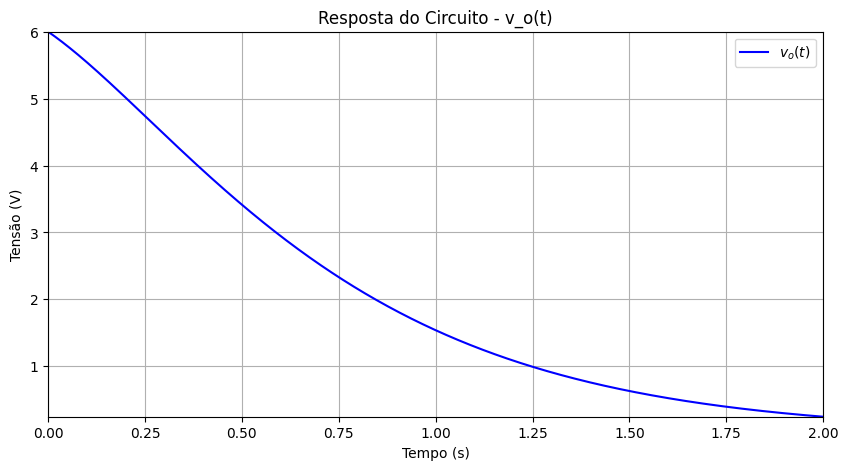

In [ ]:
#Letra b
t_plot = np.linspace(0, 2, 1000)

def analitica(t):
    return (44/3)*np.exp(-2*t) + (1/3)*np.exp(-5*t) - 9*np.exp(-3*t)

y_vals = analitica(t_plot)

plt.figure(figsize=(10, 5))
plt.plot(t_plot, y_vals, label=r'$v_o(t)$', color='blue')
plt.xlim(0, 2)
plt.ylim(y_vals.min(), y_vals.max())
plt.title('Resposta do Circuito - v_o(t)')
plt.xlabel('Tempo (s)')
plt.ylabel('Tensão (V)')
plt.grid(True)
plt.legend()
plt.show()

### Letra c

In [13]:
t_sym = sp.symbols('t', real=True, positive=True)
vo = sp.Function('vo')(t_sym)  
vi = 6 * sp.exp(-3 * t_sym)

lado_esquerdo = vo.diff(t_sym, 2) + 7 * vo.diff(t_sym) + 10 * vo
lado_direito = vi.diff(t_sym) + 6 * vi

edo = sp.Eq(lado_esquerdo, lado_direito)

condicoes_iniciais = {
    vo.subs(t_sym, 0): 6, 
    vo.diff(t_sym).subs(t_sym, 0): -4
}

sol_simbolica = sp.dsolve(edo, ics=condicoes_iniciais)

sol_final = sol_simbolica[0] if isinstance(sol_simbolica, list) else sol_simbolica

print("Expressão analítica obtida via SymPy:")
display(sol_final)


v_simb_func = sp.lambdify(t_sym, sol_final.rhs, 'numpy')

erro_max = np.abs(y_vals - v_simb_func(t_plot)).max()
print(f"Erro máximo de comparação: {erro_max:.2e}")

Expressão analítica obtida via SymPy:


Eq(vo(t), (44/3 - 9*exp(-t) + exp(-3*t)/3)*exp(-2*t))

Erro máximo de comparação: 2.66e-15
